In [1]:
# %%
import os, gc, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW

from transformers import RobertaTokenizer, RobertaModel
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.metrics import precision_recall_fscore_support, ConfusionMatrixDisplay
from tabulate import tabulate

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
print(f"Available GPUs: {torch.cuda.device_count()}")


2025-09-07 07:14:49.704492: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757229289.726895    1602 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757229289.733701    1602 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Available GPUs: 2


In [2]:

config = {
    "model_name": "roberta-large",  # or "roberta-base"
    "epochs": 15,
    "batch_size": 128,
    "max_length": 128,
    "k_folds": 15,
    "learning_rate": 1e-5,
    "early_stop_patience": 3,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "seed": 42,
    "use_amp": True
}

random.seed(config["seed"])
np.random.seed(config["seed"])
torch.manual_seed(config["seed"])
torch.cuda.manual_seed_all(config["seed"])


In [3]:
# %%
df = pd.read_csv("/kaggle/input/promise_nfr_original.csv", sep=";")
print(f"✅ Loaded {len(df)} samples")

# F = 1 (Functional), others = 0 (NFR)
df["label"] = df["class"].apply(lambda x: 1 if x == "F" else 0)
df.dropna(subset=["RequirementText", "label"], inplace=True)

print(f"✅ After filtering: {len(df)} rows")
print("📊 Class distribution:\n", df["label"].value_counts())
print("🧠 Unique original class types:\n", df["class"].value_counts())


✅ Loaded 625 samples
✅ After filtering: 625 rows
📊 Class distribution:
 label
0    370
1    255
Name: count, dtype: int64
🧠 Unique original class types:
 class
F     255
US     67
SE     66
O      62
PE     54
LF     38
A      21
SC     21
MN     17
L      13
FT     10
PO      1
Name: count, dtype: int64


In [4]:
# %%
tokenizer = RobertaTokenizer.from_pretrained(config["model_name"])

class RequirementsDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts.tolist(), truncation=True, padding=True, max_length=config["max_length"])
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [5]:
class RoBERTa_BiLSTM_Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(config["model_name"], add_pooling_layer=False)
        self.lstm = nn.LSTM(self.roberta.config.hidden_size, 128, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(256, 1)
        self.classifier = nn.Linear(256, 1)

    def forward(self, input_ids, attention_mask):
        roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        lstm_out, _ = self.lstm(roberta_output)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        logits = self.classifier(context)
        return logits.squeeze(-1)


In [6]:
# %%
def train_fn(model, dataloader, optimizer, criterion, scaler, fold, epoch):
    model.train()
    total_loss = 0
    pbar = tqdm(dataloader, desc=f"🟡 Fold {fold+1} | Epoch {epoch+1} [Train]", leave=False)

    for batch in pbar:
        input_ids = batch['input_ids'].to(config["device"])
        attention_mask = batch['attention_mask'].to(config["device"])
        labels = batch['labels'].float().to(config["device"])

        optimizer.zero_grad()
        with autocast(enabled=config["use_amp"]):
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

        if config["use_amp"]:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return total_loss / len(dataloader)

def eval_fn(model, dataloader, criterion, fold, epoch):
    model.eval()
    preds, trues = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"🔵 Fold {fold+1} | Epoch {epoch+1} [Eval]", leave=False):
            input_ids = batch['input_ids'].to(config["device"])
            attention_mask = batch['attention_mask'].to(config["device"])
            labels = batch['labels'].float().to(config["device"])

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds += torch.sigmoid(outputs).round().cpu().numpy().tolist()
            trues += labels.cpu().numpy().tolist()

    f1 = f1_score(trues, preds)
    return total_loss / len(dataloader), f1, preds, trues


In [7]:
# %%
skf = StratifiedKFold(n_splits=config["k_folds"], shuffle=True, random_state=config["seed"])
scaler = GradScaler()

fold_metrics = {"fold": [], "precision": [], "recall": [], "f1": []}
all_preds, all_trues = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(df['RequirementText'], df['label'])):
    print(f"\n🟦 Fold {fold+1}/{config['k_folds']} ==============================")

    train_ds = RequirementsDataset(df.iloc[train_idx]['RequirementText'], df.iloc[train_idx]['label'])
    val_ds = RequirementsDataset(df.iloc[val_idx]['RequirementText'], df.iloc[val_idx]['label'])

    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=config["batch_size"], num_workers=0)

    model = RoBERTa_BiLSTM_Attention()
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model = model.to(config["device"])

    optimizer = AdamW(model.parameters(), lr=config["learning_rate"])
    criterion = nn.BCEWithLogitsLoss()

    best_f1 = 0
    early_stop = 0

    for epoch in range(config["epochs"]):
        train_loss = train_fn(model, train_loader, optimizer, criterion, scaler, fold, epoch)
        val_loss, val_f1, preds, trues = eval_fn(model, val_loader, criterion, fold, epoch)

        print(f"Epoch {epoch+1:02d} | 🔵 Val Loss: {val_loss:.4f} | 🟢 F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1, best_preds, best_trues = val_f1, preds, trues
            early_stop = 0
        else:
            early_stop += 1
            if early_stop >= config["early_stop_patience"]:
                print("🛑 Early stopping.")
                break

    precision = precision_score(best_trues, best_preds)
    recall = recall_score(best_trues, best_preds)
    f1 = f1_score(best_trues, best_preds)

    print(f"📊 Fold {fold+1} → Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print("📋 Classification Report:\n", classification_report(
        best_trues,
        best_preds,
        labels=[0, 1],
        target_names=["NFR", "F"],
        zero_division=0  # avoid division by zero errors
    ))

    fold_metrics["fold"].append(fold + 1)
    fold_metrics["precision"].append(precision)
    fold_metrics["recall"].append(recall)
    fold_metrics["f1"].append(f1)

    all_preds += best_preds
    all_trues += best_trues

    # del model
    torch.cuda.empty_cache()
    gc.collect()



🟦 Fold 1/15 ==============================


🟡 Fold 1 | Epoch 1 [Train]:   0%|          | 0/5 [00:00<?, ?it/s]

🔵 Fold 1 | Epoch 1 [Eval]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 01 | 🔵 Val Loss: 0.6499 | 🟢 F1: 0.0000


🟡 Fold 1 | Epoch 2 [Train]:   0%|          | 0/5 [00:00<?, ?it/s]

...

🔵 Fold 15 | Epoch 8 [Eval]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 08 | 🔵 Val Loss: 0.1702 | 🟢 F1: 0.9412


🟡 Fold 15 | Epoch 9 [Train]:   0%|          | 0/5 [00:00<?, ?it/s]

🔵 Fold 15 | Epoch 9 [Eval]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 09 | 🔵 Val Loss: 0.2518 | 🟢 F1: 0.9032
🛑 Early stopping.
📊 Fold 15 → Precision: 0.9412, Recall: 0.9412, F1: 0.9412
📋 Classification Report:
               precision    recall  f1-score   support

         NFR       0.96      0.96      0.96        24
           F       0.94      0.94      0.94        17

    accuracy                           0.95        41
   macro avg       0.95      0.95      0.95        41
weighted avg       0.95      0.95      0.95        41




📋 F1 Score Table for NFR (0):
╒═════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Class   │   Precision │   Recall │   F1 Score │   Support │
╞═════════╪═════════════╪══════════╪════════════╪═══════════╡
│ NFR (0) │      0.9624 │   0.9676 │      0.965 │       370 │
╘═════════╧═════════════╧══════════╧════════════╧═══════════╛

📋 F1 Score Table for F (1):
╒═════════╤═════════════╤══════════╤════════════╤═══════════╕
│ Class   │   Precision │   Recall │   F1 Score │   Support │
╞═════════╪═════════════╪══════════╪════════════╪═══════════╡
│ F (1)   │      0.9526 │   0.9451 │     0.9488 │       255 │
╘═════════╧═════════════╧══════════╧════════════╧═══════════╛


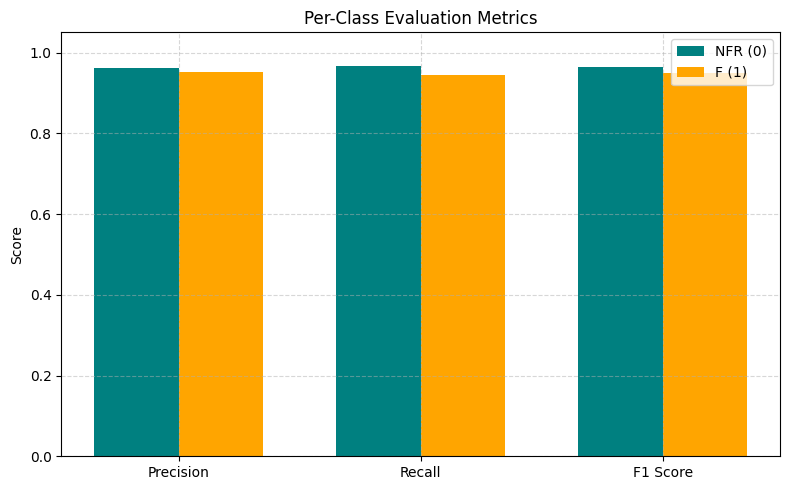

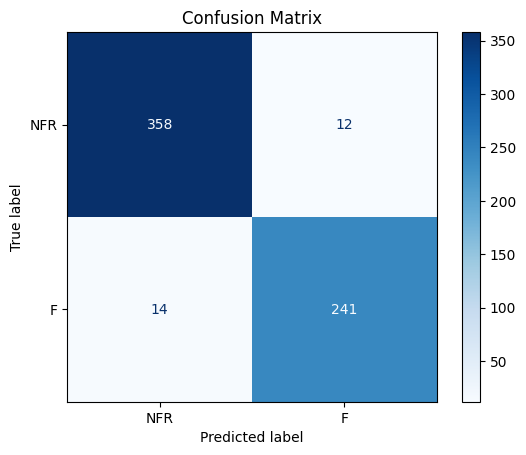

In [8]:

# Compute final class-wise metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_trues, all_preds, labels=[0, 1], zero_division=0
)

labels = ["NFR (0)", "F (1)"]
class_scores = []

for i, label in enumerate(labels):
    class_scores.append({
        "Class": label,
        "Precision": round(precision[i], 4),
        "Recall": round(recall[i], 4),
        "F1 Score": round(f1[i], 4),
        "Support": support[i]
    })

# Print tabulated results
print("\n📋 F1 Score Table for NFR (0):")
print(tabulate([class_scores[0]], headers="keys", tablefmt="fancy_grid"))

print("\n📋 F1 Score Table for F (1):")
print(tabulate([class_scores[1]], headers="keys", tablefmt="fancy_grid"))

# Plot per-class bar chart
metrics = ["Precision", "Recall", "F1 Score"]
nfr_vals = [precision[0], recall[0], f1[0]]
f_vals = [precision[1], recall[1], f1[1]]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, nfr_vals, width, label="NFR (0)", color="teal")
ax.bar(x + width / 2, f_vals, width, label="F (1)", color="orange")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-Class Evaluation Metrics")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    all_trues,
    all_preds,
    display_labels=["NFR", "F"],
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


In [21]:
import shap

gc.collect()
torch.cuda.empty_cache()


pd.set_option("display.max_colwidth", None)  # show full text in DataFrame

# ==============================
# 🟢 FINAL MODEL TRAINING ON FULL DATA
# ==============================
print("\n🟢 Training final model on full dataset for SHAP explanations...")

full_dataset = RequirementsDataset(df['RequirementText'], df['label'])
full_loader = DataLoader(full_dataset, batch_size=32,
                         shuffle=True, num_workers=0, pin_memory=True)

final_model = RoBERTa_BiLSTM_Attention().to(config["device"])
optimizer = AdamW(final_model.parameters(), lr=config["learning_rate"])
criterion = nn.BCEWithLogitsLoss()

for epoch in range(config["epochs"]):
    train_loss = train_fn(final_model, full_loader, optimizer,
                      criterion, scaler, fold=-1, epoch=epoch)

    print(f"Final Training Epoch {epoch+1}/{config['epochs']} | Loss: {train_loss:.4f}")

# ==============================
# 🔍 SHAP Explainability on Final Model
# ==============================
try:
    final_model.eval()

    # Prediction wrapper (keeps shape (n,1) for SHAP)
    def predict(texts):
        enc = tokenizer(list(texts), truncation=True, padding=True,
                        max_length=config["max_length"], return_tensors="pt")
        enc = {k: v.to(config["device"]) for k, v in enc.items()}
        with torch.no_grad():
            outputs = final_model(enc["input_ids"], enc["attention_mask"])
            probs = torch.sigmoid(outputs).cpu().numpy()
        return probs.reshape(-1, 1)

    # Background set + masker
    background = df['RequirementText'].sample(20, random_state=42).tolist()
    masker = shap.maskers.Text(tokenizer)
    explainer = shap.Explainer(predict, masker, algorithm="partition",
                               output_names=["prob_class_1"])

    # Test samples
    sample_df = df.sample(10, random_state=0)
    test_samples = sample_df["RequirementText"].tolist()
    true_labels = sample_df["label"].tolist()

    # Run SHAP
    shap_values = explainer(test_samples)

    # Collect explanations
    table_rows = []
    preds = (predict(test_samples) > 0.5).astype(int).flatten()

    for i, text in enumerate(test_samples):
        token_scores = list(zip(shap_values.data[i], shap_values.values[i]))
        token_scores_sorted = sorted(token_scores, key=lambda x: abs(x[1]), reverse=True)

        positive_tokens = [tok for tok, score in token_scores_sorted if score > 0][:5]
        negative_tokens = [tok for tok, score in token_scores_sorted if score < 0][:5]

        if preds[i] == 1:  # Functional
            rationale = (
                f"Predicted **Functional** due to terms like {', '.join(positive_tokens)} "
                f"that describe concrete actions or measurable constraints."
            )
            if negative_tokens:
                rationale += f" Less weight was given to terms like {', '.join(negative_tokens)}."
        else:  # Non-Functional
            rationale = (
                f"Predicted **Non-Functional** due to quality-related terms like {', '.join(positive_tokens)}, "
                f"highlighting performance/attributes instead of actions."
            )
            if negative_tokens:
                rationale += f" Words like {', '.join(negative_tokens)} were down-weighted."

        table_rows.append({
            "Requirement": text,
            "Actual Class": "Functional" if true_labels[i] == 1 else "Non-Functional",
            "Predicted Class": "Functional" if preds[i] == 1 else "Non-Functional",
            "Explanation": rationale
        })

    shap_table = pd.DataFrame(table_rows)
    display(shap_table)
    shap_table.to_csv("shap_explanations_final.csv", index=False)

    # Optional global viz
    shap.plots.beeswarm(shap_values)

except Exception as e:
    print(f"⚠️ SHAP failed on final model: {e}")



🟢 Training final model on full dataset for SHAP explanations...


🟡 Fold 0 | Epoch 1 [Train]:   0%|          | 0/20 [00:00<?, ?it/s]

Final Training Epoch 1/15 | Loss: 0.6263


🟡 Fold 0 | Epoch 2 [Train]:   0%|          | 0/20 [00:00<?, ?it/s]

Final Training Epoch 2/15 | Loss: 0.3687


...

PartitionExplainer explainer: 100%|██████████| 10/10 [00:43<00:00,  4.89s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [00:50,  5.56s/it]                        


,Requirement,Actual Class,Predicted Class,Explanation
0,The System shall meet all applicable accounting standards. The final version of the System must successfully pass independent audit performed by a certified auditor.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like Ġfinal, Ġaudit, Ġauditor, Ġof, Ġperformed, highlighting performance/attributes instead of actions. Words like Ġstandards, Ġapplicable, Ġaccounting, Ġsuccessfully, Ġversion were down-weighted."
1,The product must be able to interface with any HTML browser. The product shall transmit data between the user and the product without problems. The product shall display HTML properly in 80% of all HTML browsers tested (minimum is to test 8 browsers).,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like Ġbetween, Ġ8, Ġtest, Ġto, Ġand, highlighting performance/attributes instead of actions. Words like ĠHTML, ĠHTML, Ġwithout, Ġbrowser, Ġproperly were down-weighted."
2,Only registered customers can purchase streaming movies.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like Ġpurchase, Ġmovies, , Ġregistered, highlighting performance/attributes instead of actions. Words like Only, Ġcustomers, Ġcan, ., Ġstreaming were down-weighted."
3,The product shall be able to be installed in any operating environment within 2 days.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like Ġenvironment, Ġto, Ġany, The, Ġbe, highlighting performance/attributes instead of actions. Words like Ġinstalled, Ġoperating, Ġwithin, Ġdays, Ġ2 were down-weighted."
4,Only authorized personnel can access sales information.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like Ġpersonnel, ., Ġcan, , highlighting performance/attributes instead of actions. Words like Only, Ġaccess, Ġsales, Ġinformation, Ġauthorized were down-weighted."
5,90% of untrained realtors shall be able to install the product on their device without printed instructions,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like Ġshall, Ġprinted, ors, Ġreal, Ġto, highlighting performance/attributes instead of actions. Words like Ġinstall, Ġwithout, Ġdevice, 90, Ġthe were down-weighted."
6,The product shall free of computer viruses.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like ., Ġshall, Ġproduct, , The, highlighting performance/attributes instead of actions. Words like Ġcomputer, Ġviruses, Ġfree, Ġof, were down-weighted."
7,Website shall allow customers to purchase pre-paid cards of $5 $10 or $20 value either by credit card or mail-in payment option.,Functional,Functional,"Predicted **Functional** due to terms like , Ġvalue, Ġpayment, Ġoption, paid that describe concrete actions or measurable constraints. Less weight was given to terms like ., Ġby, Ġor, Ġcard, Ġmail."
8,On a 112k connection or faster the system response time for all operations must be no more than 3 seconds 90% of the time.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like Ġtime, , Ġof, Ġresponse, Ġ, highlighting performance/attributes instead of actions. Words like Ġfaster, Ġmust, Ġseconds, Ġoperations, Ġno were down-weighted."
9,Users shall feel satisfied using the product. 85% of all users will be satisfied with the product.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like Ġsatisfied, Ġ, Users, Ġusing, Ġof, highlighting performance/attributes instead of actions. Words like Ġsatisfied, Ġproduct, Ġusers, Ġwill, Ġwith were down-weighted."


⚠️ SHAP failed on final model: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!
